<a href="https://colab.research.google.com/github/Tahvia127/BUSN-20800-Final-Project-/blob/Vadim/notebooks/02_alignment_descriptive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
tier1 = pd.read_parquet('tier1.parquet')
un_panel = pd.read_parquet('un_panel.parquet')
wb_sector = pd.read_parquet('wb_sector_year.parquet')

print('tier1:', tier1.shape)
print(tier1.columns.tolist())
print('\nun_panel:', un_panel.shape)
print(un_panel.columns.tolist())
print('\nwb_sector:', wb_sector.shape)
print(wb_sector.columns.tolist())

tier1: (26, 12)
['year', 'segment', 'n_meetings', 'n_tokens', 'sentiment', 'lex_development', 'lex_humanitarian', 'lex_climate', 'lex_gender', 'lex_conflict', 'lex_health', 'lex_governance']

un_panel: (244, 8)
['agency', 'year', 'revenue_usd', 'n_subagencies', 'rev_assessed_contributions', 'rev_revenue_from_other_activities', 'rev_voluntary_core_(un_earmarked)_contributions', 'rev_voluntary_non_core_(earmarked)_contributions']

wb_sector: (3375, 5)
['sector', 'year', 'totalamt_sum', 'grantamt_sum', 'project_count']


In [9]:
lex_cols = ['lex_development', 'lex_humanitarian', 'lex_climate',
            'lex_gender', 'lex_conflict', 'lex_health', 'lex_governance']
topic_by_year = tier1.set_index('year')[lex_cols]
un_rev = un_panel.pivot_table(index='year', columns='agency', values='revenue_usd')
topic_norm = topic_by_year.div(topic_by_year.sum(axis=1), axis=0)
un_norm = un_rev.div(un_rev.sum(axis=1), axis=0)

print('topic_norm shape:', topic_norm.shape)
print('un_norm shape:', un_norm.shape)
print(topic_norm.head(2))

topic_norm shape: (26, 7)
un_norm shape: (14, 19)
      lex_development  lex_humanitarian  lex_climate  lex_gender  \
year                                                               
2000         0.133929          0.089286     0.000000    0.005952   
2001         0.441866          0.131148     0.032787    0.051198   

      lex_conflict  lex_health  lex_governance  
year                                            
2000      0.172619    0.589286        0.008929  
2001      0.110719    0.150567        0.081715  


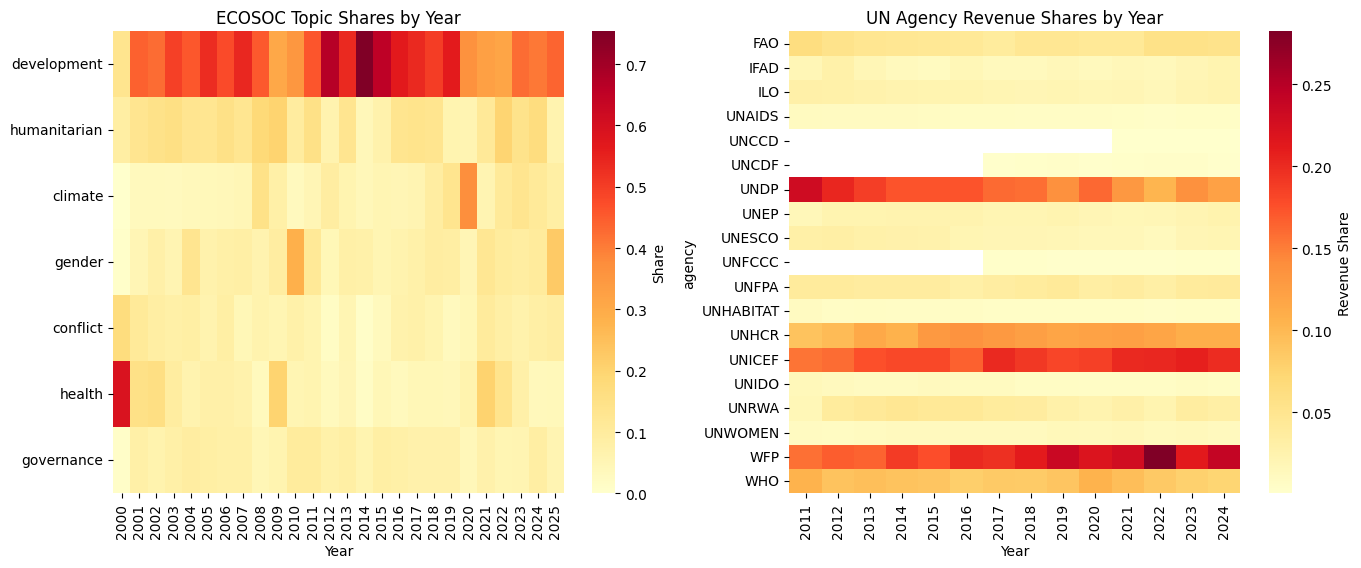

Saved fig1


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(topic_norm.T, ax=ax1, cmap='YlOrRd',
            cbar_kws={'label': 'Share'},
            yticklabels=[c.replace('lex_', '') for c in lex_cols])
ax1.set_title('ECOSOC Topic Shares by Year')
ax1.set_xlabel('Year')

sns.heatmap(un_norm.T, ax=ax2, cmap='YlOrRd',
            cbar_kws={'label': 'Revenue Share'})
ax2.set_title('UN Agency Revenue Shares by Year')
ax2.set_xlabel('Year')

plt.savefig('fig1_topic_vs_un_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig1')

In [15]:
import json
import os

# Load WB data directly from raw JSON files (fixes the all-zero bug)
rows = []
for fname in sorted(os.listdir('/content')):
    if not fname.endswith('.json'):
        continue
    with open(f'/content/{fname}') as f:
        data = json.load(f)
    for pid, proj in data.get('projects', {}).items():
        amt_str = str(proj.get('totalamt', '0')).replace(',', '')
        try:
            totalamt = float(amt_str) if amt_str else 0.0
        except ValueError:
            totalamt = 0.0
        sector = proj.get('sector1', {})
        sector_name = sector.get('Name', 'Unknown') if isinstance(sector, dict) else 'Unknown'
        date_str = proj.get('boardapprovaldate', '')
        year = int(date_str[:4]) if date_str and len(date_str) >= 4 else None
        rows.append({'sector': sector_name, 'year': year, 'totalamt': totalamt})

wb_df = pd.DataFrame(rows).dropna(subset=['year'])
wb_df['year'] = wb_df['year'].astype(int)
wb_df = wb_df[wb_df['year'] >= 2000]
wb_df = wb_df[wb_df['sector'] != '']
wb_df = wb_df[wb_df['sector'] != 'Unknown']
wb_df = wb_df[wb_df['sector'].str.strip() != '']

print('WB rows loaded:', len(wb_df))
print('Sample totalamt:', wb_df['totalamt'].describe())

WB rows loaded: 8007
Sample totalamt: count    8.007000e+03
mean     1.051222e+08
std      1.714593e+08
min      0.000000e+00
25%      1.000000e+07
50%      4.500000e+07
75%      1.250000e+08
max      3.750000e+09
Name: totalamt, dtype: float64


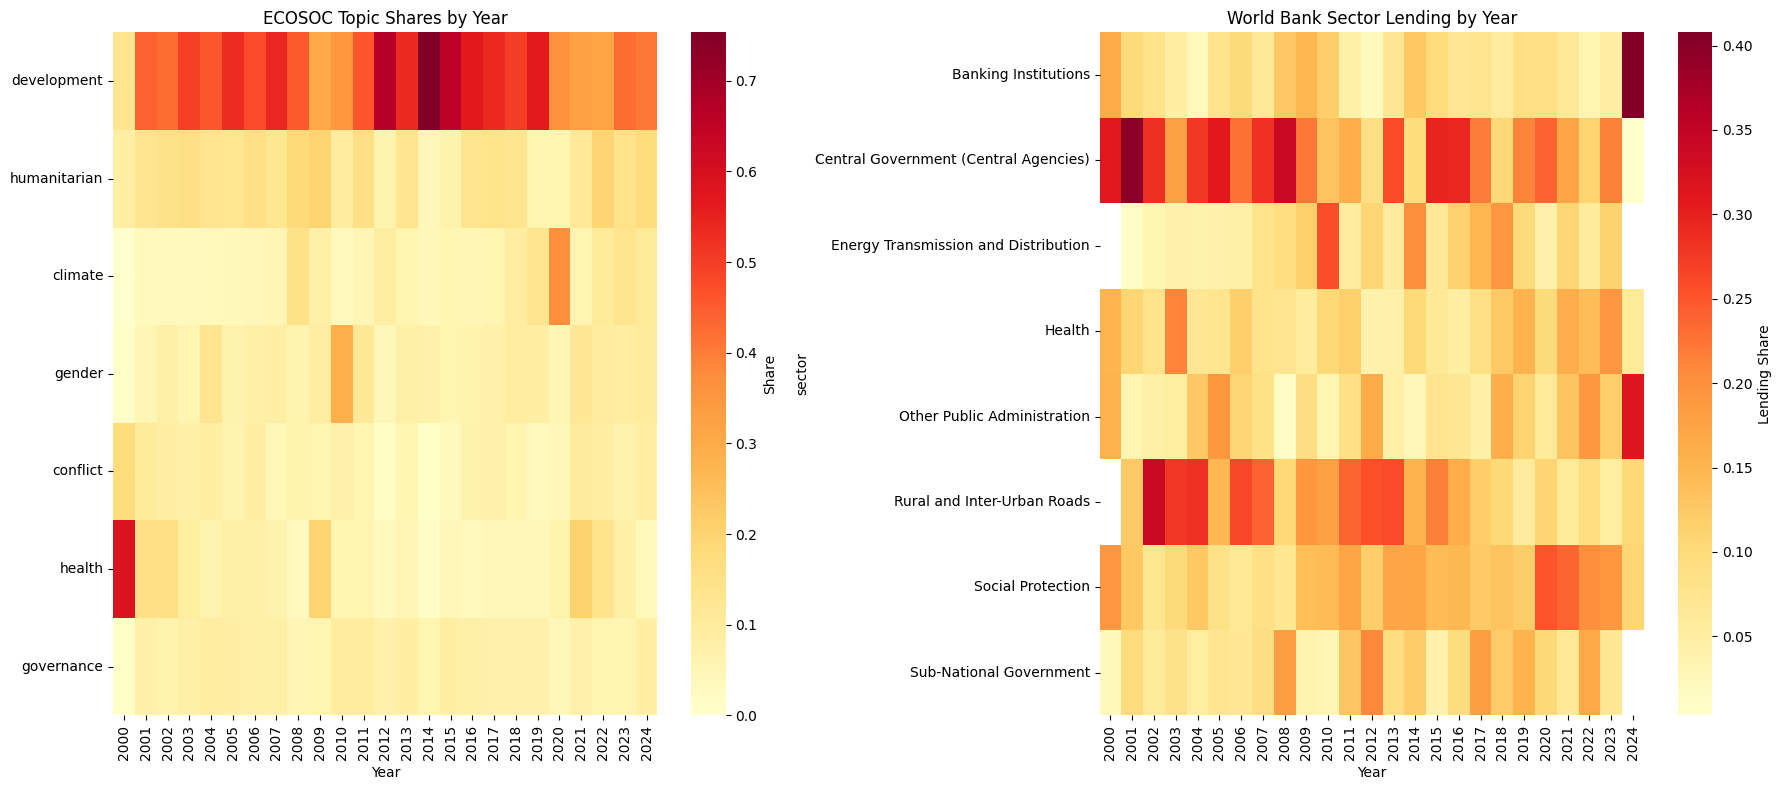

Saved fig2


In [17]:
common_years = sorted(set(topic_norm.index) & set(wb_share.index))
topic_wb = topic_norm.loc[common_years]
wb_wb = wb_share.loc[common_years]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(topic_wb.T, ax=ax1, cmap='YlOrRd',
            cbar_kws={'label': 'Share'},
            yticklabels=[c.replace('lex_', '') for c in lex_cols])
ax1.set_title('ECOSOC Topic Shares by Year')
ax1.set_xlabel('Year')

sns.heatmap(wb_wb.T, ax=ax2, cmap='YlOrRd',
            cbar_kws={'label': 'Lending Share'})
ax2.set_title('World Bank Sector Lending by Year')
ax2.set_xlabel('Year')

plt.tight_layout()
plt.savefig('fig2_topic_vs_wb_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig2')

In [13]:
!pip install umap-learn -q

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


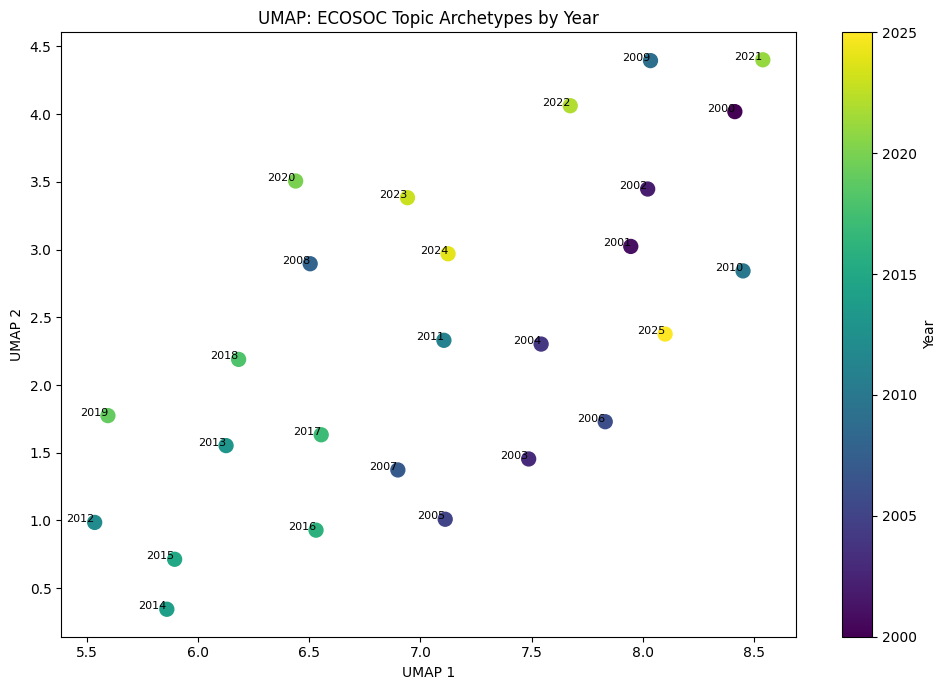

Saved fig3


In [14]:
import umap
import numpy as np

X = topic_norm.fillna(0).values
years = topic_norm.index.tolist()

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(X)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(embedding[:, 0], embedding[:, 1],
                     c=years, cmap='viridis', s=100)
plt.colorbar(scatter, ax=ax, label='Year')

for i, year in enumerate(years):
    ax.annotate(str(year), (embedding[i, 0], embedding[i, 1]),
                fontsize=8, ha='right')

ax.set_title('UMAP: ECOSOC Topic Archetypes by Year')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')

plt.tight_layout()
plt.savefig('fig3_umap_archetypes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig3')